# Step 4 - The Prophet-then-XGB sequential pipeline

This is one of four `step4_model_*` notebooks, one per model architecture. Read them after step 1 (data splitting), step 2 (cross-validation), and step 3 (hyperparameter tuning -- demoed on `prophet_xgb`; the same search space applies here). Step 3 shows *where* a final set of hyperparameters comes from; here we fit with the package defaults from `params.yaml`. To use tuned parameters, pass `config_overrides={"models": {"prophet_then_xgb": best_params}}` into `run_single_its()`.

**Goal:** walk through `run_single_its()` using the `ProphetThenXGBModel`.

Sections:
- **4a.** Load the pre-built dummy data.
- **4b.** Fit `ProphetThenXGBModel` manually and inspect the `FitResult`.
- **4c.** Inside ProphetThenXGB -- sequential stages vs. the hybrid.
- **4d.** Run the full pipeline via `run_single_its()`.
- **4e.** Inspect `PipelineResult`: metrics, excess table, ATE.
- **4f.** Reproduce the counterfactual plot with annotations.

In [1]:
%matplotlib inline

from IPython.display import display
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(name)s - %(message)s",
    datefmt="%H:%M:%S",
)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("its2s").setLevel(logging.WARNING)

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

## 4a. Load the pre-built dummy data

The series has a +8/day intervention effect baked in for 42 days after 2022-03-15.

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset (with +8/day intervention effect)")
print("=" * 60)
print(df.tail())

Dummy dataset (with +8/day intervention effect)
             ds          y  covar_linear  covar_dow  covar_noise
1571 2022-04-21  71.975041      0.995182        3.0    -0.356611
1572 2022-04-22  73.042307      1.033630        4.0     0.247103
1573 2022-04-23  72.275013      1.003513        5.0     1.129482
1574 2022-04-24  69.332534      1.004775        6.0    -0.321536
1575 2022-04-25  69.651058      0.981820        0.0    -1.057655


## 4b. Manual fit

This replicates what `run_single_its` does internally, so we can inspect the `FitResult`.

In [3]:
from its2s.data_prep import prepare_splits
from its2s.models.prophet_then_xgb import ProphetThenXGBModel
from its2s.settings import get_model_config, load_config

config = load_config()
splits = prepare_splits(df, INTERVENTION, test_days=TEST_DAYS, holdout_days=HOLDOUT_DAYS)

model_params = get_model_config(config, "prophet_then_xgb")
model = ProphetThenXGBModel(params=model_params)

print("Fitting ProphetThenXGBModel on training data ...")
print(f"  Training rows : {len(splits.train_df)}")
print(f"  Training range: {splits.train_df['ds'].min().date()} -> {splits.train_df['ds'].max().date()}")

fit_result = model.fit(splits.train_df, target_col="y", date_col="ds")

print("\nFitResult fields:")
print(f"  fitted_values  shape = {fit_result.fitted_values.shape}")
print(f"  residuals      shape = {fit_result.residuals.shape}")
print(f"  residuals  mean={fit_result.residuals.mean():.4f}  std={fit_result.residuals.std():.4f}")
print(f"  model_object keys: {list(fit_result.model_object.keys())}")

Fitting ProphetThenXGBModel on training data ...
  Training rows : 1227
  Training range: 2018-01-01 -> 2021-05-11



FitResult fields:
  fitted_values  shape = (1227,)
  residuals      shape = (1227,)
  residuals  mean=-0.0006  std=1.2201
  model_object keys: ['prophet', 'xgb']


## 4c. Inside ProphetThenXGB -- sequential stages vs. the hybrid

**Architecture comparison:**

| Model | Stage 1 | Stage 2 | XGB input |
|---|---|---|---|
| `ProphetXGBHybrid` | Prophet fits trend+seasonality | XGB fits `y - Prophet_yhat` (residuals from decomposition) | time features only |
| `ProphetThenXGB` | Prophet makes **standalone forecast** | XGB corrects **Prophet's forecast errors** | time features + `prophet_forecast` as a feature |

The key distinction: in the hybrid, XGB models unexplained residual structure. In the
sequential model, Prophet makes its best guess first and XGB corrects what Prophet got wrong.

In [4]:
prophet_model = fit_result.model_object["prophet"]
xgb_model     = fit_result.model_object["xgb"]

# Reconstruct Prophet's standalone in-sample forecast
prophet_input = splits.train_df[["ds"]].copy()
prophet_input["ds"] = pd.to_datetime(prophet_input["ds"])
prophet_forecast = prophet_model.predict(prophet_input)["yhat"].values

raw_y           = splits.train_df["y"].values
stage1_errors   = raw_y - prophet_forecast   # what XGB was trained to correct
final_residuals = fit_result.residuals       # what remained after XGB correction

print(f"  Stage-1 errors  (y - Prophet forecast)           std = {stage1_errors.std():.4f}")
print(f"  Stage-2 residuals (y - Prophet - XGB correction) std = {final_residuals.std():.4f}")
print("  -> XGB reduces error variance from stage 1 to stage 2")

# XGB feature importances -- note prophet_forecast is included as a feature
xgb_feat_names = ["day_of_week", "day_of_year", "month", "week_of_year", "prophet_forecast"]
importances = pd.Series(xgb_model.feature_importances_, index=xgb_feat_names).sort_values(ascending=False)
print("\n  XGB feature importances:")
print(importances.to_string())

  Stage-1 errors  (y - Prophet forecast)           std = 1.9591
  Stage-2 residuals (y - Prophet - XGB correction) std = 1.2201
  -> XGB reduces error variance from stage 1 to stage 2

  XGB feature importances:
prophet_forecast    0.214055
month               0.203918
day_of_year         0.201032
week_of_year        0.194824
day_of_week         0.186170


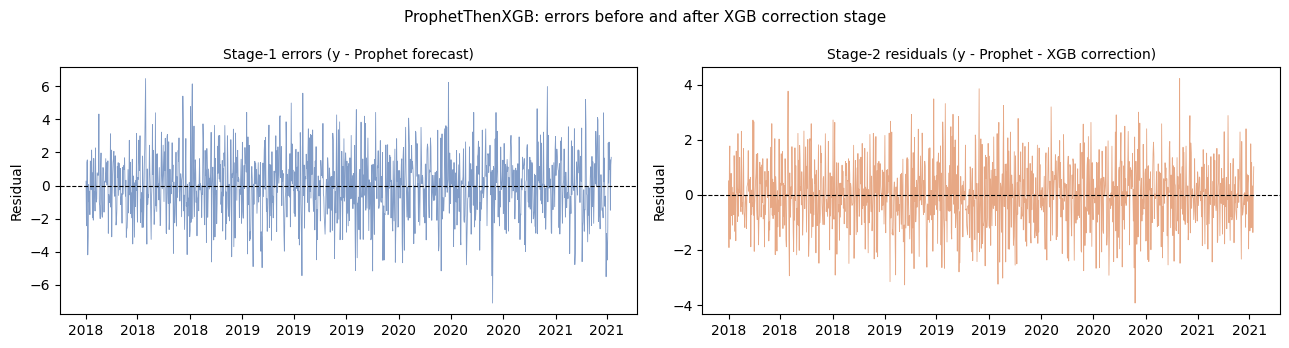

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, resid, title, color in [
    (axes[0], stage1_errors,   "Stage-1 errors (y - Prophet forecast)", "#4C72B0"),
    (axes[1], final_residuals, "Stage-2 residuals (y - Prophet - XGB correction)", "#DD8452"),
]:
    ax.plot(splits.train_df["ds"], resid, linewidth=0.6, color=color, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Residual")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("ProphetThenXGB: errors before and after XGB correction stage", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "prophet_then_xgb_residuals.png", dpi=150)
display(fig)

## 4d. Full pipeline run

MBB bootstrap runs with `n_sim=100` for speed; production use should set this to 1000+.

In [6]:
from its2s import run_single_its

result = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name="prophet_then_xgb",
    config_overrides={
        "bootstrap": {"n_sim": 100},
        "periods":   {"test_days": TEST_DAYS, "holdout_days": HOLDOUT_DAYS},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print("PipelineResult fields:")
print(f"  model_name       : {result.model_name}")
print(f"  fit_result       : FitResult with {len(result.fit_result.fitted_values)} fitted values")
print(f"  bootstrap_result : BootstrapCIResult  pred_matrix shape = {result.bootstrap_result.pred_matrix.shape}")
print(f"  metrics_train    : {result.metrics_train}")
print(f"  metrics_test     : {result.metrics_test}")

12:18:22  WARNING  its2s.diagnostics - Ljung-Box test (p=0.0000) suggests significant residual autocorrelation for model 'prophet_then_xgb'. Bootstrap CIs may undercover.


PipelineResult fields:
  model_name       : prophet_then_xgb
  fit_result       : FitResult with 1227 fitted values
  bootstrap_result : BootstrapCIResult  pred_matrix shape = (349, 100)
  metrics_train    : MetricsResult(rmse=1.2201056878265537, mae=0.9624954419677986, mape=1.8741114515561947, smape=1.8717374655443202, mase=None, r2=0.9727649791237548)
  metrics_test     : MetricsResult(rmse=2.2490089856343927, mae=1.8003661397627078, mape=3.496397508939152, smape=3.4841340289624627, mase=0.7795765670825092, r2=0.8827034572148785)


## 4e. Metrics and excess table

In [7]:
metrics_df = pd.DataFrame({
    "RMSE":  [result.metrics_train.rmse,  result.metrics_test.rmse],
    "MAE":   [result.metrics_train.mae,   result.metrics_test.mae],
    "MAPE":  [result.metrics_train.mape,  result.metrics_test.mape],
    "SMAPE": [result.metrics_train.smape, result.metrics_test.smape],
    "R2":    [result.metrics_train.r2,    result.metrics_test.r2],
}, index=["Train", "Test"])
print(metrics_df.round(3).to_string())

        RMSE    MAE   MAPE  SMAPE     R2
Train  1.220  0.962  1.874  1.872  0.973
Test   2.249  1.800  3.496  3.484  0.883


In [8]:
print("Period-level excess:")
print(result.excess_table.period_excess.to_string(index=False))
print("\nDaily excess - first 10 holdout days:")
print(result.excess_table.daily_excess.head(10).to_string(index=False))

Period-level excess:
      period start_date   end_date  n_days  total_observed  total_expected  total_excess  excess_ci_lo  excess_ci_hi  excess_pct
Full holdout 2022-03-15 2022-04-25      42     3029.800778     2754.829234    274.971544    233.360934    335.652189    9.981437

Daily excess - first 10 holdout days:
      date  observed  expected  expected_ci_lo  expected_ci_hi    excess  excess_ci_lo  excess_ci_hi  excess_pct  excess_pct_ci_lo  excess_pct_ci_hi
2022-03-15 76.449700 64.625014       63.011564       66.096546 11.824687     10.353154     13.438136   18.297384         16.020351         20.794017
2022-03-16 70.565458 63.924782       62.347630       65.845682  6.640676      4.719776      8.217829   10.388266          7.383327         12.855466
2022-03-17 74.032036 64.283768       63.079861       66.003092  9.748268      8.028943     10.952175   15.164431         12.489846         17.037233
2022-03-18 69.205309 64.983636       63.298132       66.593609  4.221673      2.611700

In [9]:
from its2s.metrics.excess import calc_ate_summary

ate = calc_ate_summary(result.excess_table.daily_excess)
print("Average Treatment Effect (ATE) summary:")
print(ate.to_string(index=False))
print("\n  Total ATE      = sum of daily excess over full holdout")
print("  Mean Daily ATE = average excess per day")
print(f"  Simulated effect was +8/day for {HOLDOUT_DAYS} days -> expected total excess ~{8 * HOLDOUT_DAYS}")

Average Treatment Effect (ATE) summary:
        metric   estimate      ci_lo      ci_hi  n_days
     Total ATE 274.971544 215.994846 349.459786      42
Mean Daily ATE   6.546942   5.142734   8.320471      42

  Total ATE      = sum of daily excess over full holdout
  Mean Daily ATE = average excess per day
  Simulated effect was +8/day for 42 days -> expected total excess ~336


## 4f. Counterfactual plot (annotated)

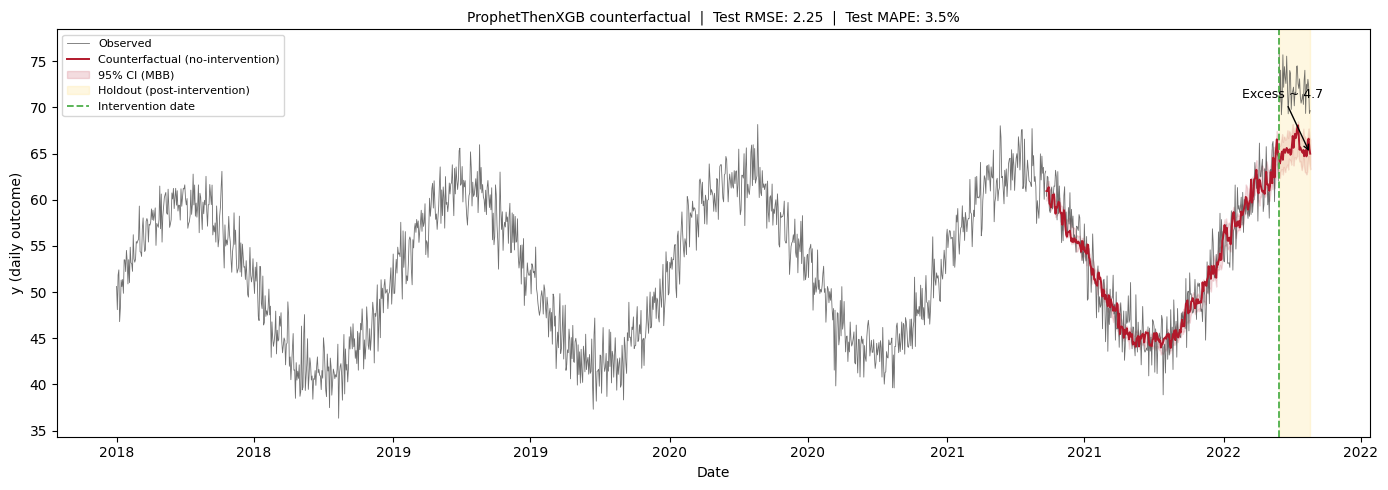

In [10]:
br = result.bootstrap_result
pred_dates = pd.to_datetime(br.dates)
intervention_ts = pd.Timestamp(INTERVENTION)

fig, ax = plt.subplots(figsize=(14, 5))

for part in [splits.train_df, splits.test_df, splits.holdout_df]:
    ax.plot(part["ds"], part["y"], color="#333333", linewidth=0.6, alpha=0.7)
ax.plot([], [], color="#333333", linewidth=0.6, alpha=0.7, label="Observed")

ax.plot(pred_dates, br.predicted, color="#B2182B", linewidth=1.4,
        label="Counterfactual (no-intervention)")
ax.fill_between(pred_dates, br.conf_lo, br.conf_hi,
                color="#B2182B", alpha=0.15, label="95% CI (MBB)")

ax.axvspan(intervention_ts, splits.holdout_df["ds"].max(),
           color="#FEE08B", alpha=0.25, label="Holdout (post-intervention)")
ax.axvline(intervention_ts, color="#4DAF4A", linestyle="--", linewidth=1.3,
           label="Intervention date")

last_date = pred_dates[pred_dates >= intervention_ts][-1]
last_obs  = splits.holdout_df.loc[splits.holdout_df["ds"] == last_date, "y"].values
last_pred = br.predicted[pred_dates == last_date]
if len(last_obs) and len(last_pred):
    ax.annotate(
        f"Excess ~ {float(last_obs[0] - last_pred[0]):.1f}",
        xy=(last_date, float(last_pred[0])),
        xytext=(last_date - pd.Timedelta(days=90), float(last_pred[0]) + 6),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.set_title(
    f"ProphetThenXGB counterfactual  |  Test RMSE: {result.metrics_test.rmse:.2f}"
    f"  |  Test MAPE: {result.metrics_test.mape:.1f}%",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "prophet_then_xgb_counterfactual.png", dpi=150)
display(fig)

## Key takeaways

1. `ProphetThenXGBModel.fit()` runs in two sequential stages: Prophet generates a complete standalone forecast first, then XGB is trained on Prophet's forecast errors.
2. The key architectural difference from the hybrid: Prophet is a full model in its own right here, not just a decomposition tool. XGB corrects what Prophet got wrong, using `prophet_forecast` as an explicit feature.
3. `FitResult.residuals` are the combined (y - Prophet - XGB correction) series -- the raw material for Moving Block Bootstrap (step 5) in step 3.
4. `run_single_its()` orchestrates: `load_config -> prepare_splits -> fit -> bootstrap -> metrics -> excess -> save`.
5. Excess = observed - counterfactual_predicted. With a true +8/day effect over 42 days, total excess should land near 336 (noise aside).